<a href="https://colab.research.google.com/github/Dokkae-bi/Intro-to-DL-Summer-26/blob/main/Final%20Project/captioning_harness_v2_1_(2)_(1)%20edit1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Captioning — Shared Experiment Harness (v2.1)

**ECGR 4106 Final Project — Anthony & Aadit**

Fixes over v2, all of which were blocking:

- Everything lives on **mounted Drive**, not `/content` (wiped on runtime reset)
- Feature cache is **bound to the filename-order hash** — shape equality alone let a mis-ordered
  cache pair every image with another image's features and pass silently
- Result JSONs store a checkpoint **filename**, not an absolute path, so they survive being copied
  between accounts
- Run IDs include `EXPERIMENT_VERSION`, so fixing a bug and rerunning no longer hits "skip (done)"
  and reports the buggy result
- Interrupted runs **resume at the epoch** they died on
- Test evaluation is gated on a **frozen manifest**, not a boolean
- Attention weights have a declared interface, so heatmap code isn't four separate hacks
- BLEU smoothing removed (a no-op at corpus level; without it a degenerate epoch with zero 4-gram
  matches warns and scores ~0, which is the correct reading)
- **v2.1a:** `torch.load(..., weights_only=False)` on our own checkpoints and `str(torch.__version__)`
  at save time. torch>=2.6 defaults `weights_only=True`, which rejects the `TorchVersion` object our
  metadata carried. Serialization only — training semantics unchanged, so **do not bump
  `EXPERIMENT_VERSION`**; completed runs stay valid.

## Responsibility checklist

**Anthony** — persistent paths, experiment definition, feature cache, loaders, training harness,
GRU baseline, baseline LR search + 3 final seeds, export artifacts, write up the data / encoder /
baseline / training / protocol sections.

**Aadit** — Luong, Bahdanau, multi-head, Transformer decoders; attention-weight plumbing; METEOR
and CIDEr; beam search; heatmaps; failure analysis; Canvas submission.

**Joint** — verify all five models share one data definition, freeze before test, interpret results,
write and proof the report.

## Protocol

1. One data definition: built once, hashed, loaded thereafter.
2. Validation-only development. Test is manifest-gated.
3. Per architecture: 3 LRs at seed 0, then **3 fresh seeds** (1, 2, 3) at the winner.
4. Paired reporting on matched seeds. At n=3 the minimum two-sided sign-test p is 0.25 — report
   magnitude and direction, never "significant."

## Report disclosures

- ResNet-50 at 224px gives a **7x7** grid (49 positions), not the 14x14 in the proposal.
- BLEU is NLTK `corpus_bleu`, brevity penalty applied, no smoothing. Comparable **across our five
  models only**.
- Preliminary baseline test scores (0.1983 / 0.1872) were computed during pipeline validation
  before this protocol existed; the test set was not entirely unseen during early development.
- `patience` and `max_epochs` were fixed **before** any architecture was implemented, so a
  slower-converging model was not disadvantaged by a rule chosen after seeing results.


## 1. Setup — persistent storage

`PROJECT_ROOT` is the only path either of you edits. A shared Drive folder mounts at different paths
for different accounts; everything downstream is relative to it, so the definition, caches,
checkpoints, and results are genuinely shared.

`EXPERIMENT_VERSION` goes into every run ID. **Bump it whenever a model implementation or the
training loop changes** — that is what stops a fixed bug from being masked by a stale result file.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/image_captioning_project"   # <-- each account sets this
EXPERIMENT_VERSION = "v2.1"                                        # <-- bump on any impl change

import os, json, re, random, time, math, hashlib, glob, statistics
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

from nltk.translate.bleu_score import corpus_bleu

CFG = {
    "project_root": PROJECT_ROOT,
    "raw_dir":     os.path.join(PROJECT_ROOT, "raw"),
    "results_dir": os.path.join(PROJECT_ROOT, "results"),
    "ckpt_dir":    os.path.join(PROJECT_ROOT, "checkpoints"),
    "min_word_freq": 5,
    "emb_dim": 256,
    "hidden_dim": 512,
    "batch_size": 64,
    "max_epochs": 30,
    "patience": 6,          # fixed before any architecture existed — see disclosures
    "grad_clip": 5.0,
    "max_decode_len": 30,
    "feature_dim": 2048,
    "num_pixels": 49,
    "encoder_weights": "ResNet50_Weights.IMAGENET1K_V2",
    "bleu_impl": "nltk.corpus_bleu/BP-applied/no-smoothing",
    "experiment_version": EXPERIMENT_VERSION,
}

# Settings NOT in CFG must be declared here so a result JSON can reconstruct the model.
MODEL_CONFIGS = {
    "gru_baseline": {"dropout": 0.3, "attention": None, "layers": 1},
}

SEARCH_SEED = 0
SEARCH_LRS  = [1e-4, 3e-4, 1e-3]
FINAL_SEEDS = [1, 2, 3]
EXPECTED_ARCHS = {"gru_baseline", "gru_luong", "gru_bahdanau", "gru_multihead", "transformer"}

for d in (CFG["raw_dir"], CFG["results_dir"], CFG["ckpt_dir"]):
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True   # speed; bit-exact reproduction is not claimed

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def sha256_json(value):
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, separators=(",", ":")).encode("utf-8")
    ).hexdigest()

print("root:", PROJECT_ROOT, "| version:", EXPERIMENT_VERSION)
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print("torch", torch.__version__, "| torchvision", torchvision.__version__)


Mounted at /content/drive
root: /content/drive/MyDrive/image_captioning_project | version: v2.1
device: cuda Tesla T4
torch 2.11.0+cu128 | torchvision 0.26.0+cu128


## 2. Download Flickr8k into Drive

Downloads only if the images aren't already there, so the second person and every later session
skip straight past.

**Storage budget:** images ~1 GB, feature cache ~1.6 GB, and each checkpoint is roughly
`params x 12 bytes` (weights plus two Adam moments) — about 50 MB for the baseline, more for the
larger decoders. Thirty runs lands around 2–4 GB, so plan on ~7 GB total. Resume checkpoints are
deleted on completion so they don't double it.


In [2]:
%cd {CFG["raw_dir"]}

IMG_DIR = os.path.join(CFG["raw_dir"], "Flicker8k_Dataset")   # the zip misspells "Flicker"

if not os.path.isdir(IMG_DIR) or len(os.listdir(IMG_DIR)) < 8000:
    !wget -nc -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
    !wget -nc -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
    !unzip -n -q Flickr8k_Dataset.zip
    !unzip -n -q Flickr8k_text.zip
    !wget -nc -q https://cs.stanford.edu/people/karpathy/deepimagesent/caption_datasets.zip || true
    import zipfile
    if os.path.exists("caption_datasets.zip") and not os.path.exists("dataset_flickr8k.json"):
        try:
            with zipfile.ZipFile("caption_datasets.zip") as z:
                z.extract("dataset_flickr8k.json")
        except zipfile.BadZipFile:
            print("Karpathy zip unreadable — official split files will be used.")

print("images on disk:", len(os.listdir(IMG_DIR)))


/content/drive/MyDrive/image_captioning_project/raw
images on disk: 8091


## 3. Experiment definition — build once, load forever

The two parsing branches tokenize differently (Karpathy ships pre-tokenized captions; the fallback
runs our regex tokenizer), so matching image membership does **not** guarantee matching captions or
vocabulary. Built once, hashed, saved. Everyone else loads.


In [3]:
ART_PATH = os.path.join(PROJECT_ROOT, "shared_experiment_definition.json")

def tokenize(s):
    return re.sub(r"[^a-z ]+", " ", s.lower()).split()

def build_definition():
    kp = os.path.join(CFG["raw_dir"], "dataset_flickr8k.json")
    splits = {"train": [], "val": [], "test": []}
    if os.path.exists(kp):
        with open(kp) as f:
            kj = json.load(f)
        for img in kj["images"]:
            sp = "train" if img["split"] == "restval" else img["split"]
            splits[sp].append((img["filename"], [s["tokens"] for s in img["sentences"]]))
        source = "karpathy"
    else:
        caps = {}
        with open(os.path.join(CFG["raw_dir"], "Flickr8k.token.txt")) as f:
            for line in f:
                if not line.strip():
                    continue
                head, cap = line.split("\t")
                caps.setdefault(head.split("#")[0], []).append(tokenize(cap))
        for sp, sf in [("train", "Flickr_8k.trainImages.txt"),
                       ("val", "Flickr_8k.devImages.txt"),
                       ("test", "Flickr_8k.testImages.txt")]:
            with open(os.path.join(CFG["raw_dir"], sf)) as f:
                for line in f:
                    fn = line.strip()
                    if fn in caps:
                        splits[sp].append((fn, caps[fn]))
        source = "official_flickr8k"

    counter = Counter()
    for _, cs in splits["train"]:
        for c in cs:
            counter.update(c)
    itos = ["<pad>", "<start>", "<end>", "<unk>"] + \
           sorted(w for w, n in counter.items() if n >= CFG["min_word_freq"])
    all_files = sorted({fn for sp in splits.values() for fn, _ in sp})
    return splits, itos, all_files, source

if os.path.exists(ART_PATH):
    with open(ART_PATH) as f:
        ART = json.load(f)
    splits = {k: [(e["filename"], e["captions"]) for e in v] for k, v in ART["splits"].items()}
    itos, all_files = ART["itos"], ART["all_files"]
    print("LOADED definition —", ART["split_source"])
else:
    splits, itos, all_files, source = build_definition()
    ser = {k: [{"filename": fn, "captions": cs} for fn, cs in v] for k, v in splits.items()}
    ART = {"cfg": CFG, "split_source": source, "splits": ser, "itos": itos,
           "all_files": all_files,
           "vocab_hash": sha256_json(itos),
           "splits_hash": sha256_json(ser),
           "file_order_hash": sha256_json(all_files),
           "torch_version": str(torch.__version__),
           "torchvision_version": str(torchvision.__version__),
           "encoder_weights": CFG["encoder_weights"],
           "feature_cache": "resnet50_feats_7x7_fp16.pt",
           "feature_shape": [len(all_files), CFG["num_pixels"], CFG["feature_dim"]]}
    with open(ART_PATH, "w") as f:
        json.dump(ART, f)
    print("BUILT definition —", source)

stoi = {w: i for i, w in enumerate(itos)}
VOCAB_SIZE = len(itos)
PAD_IDX, START_IDX, END_IDX, UNK_IDX = 0, 1, 2, 3
file_to_idx = {f: i for i, f in enumerate(all_files)}

def encode_caption(t):
    return [START_IDX] + [stoi.get(w, UNK_IDX) for w in t] + [END_IDX]

def decode_ids(ids):
    out = []
    for i in ids:
        if i == END_IDX:
            break
        if i not in (PAD_IDX, START_IDX):
            out.append(itos[i])
    return out

print("source", ART["split_source"], "| vocab", VOCAB_SIZE, ART["vocab_hash"][:12],
      "| splits", ART["splits_hash"][:12], "| order", ART["file_order_hash"][:12])
print({k: len(v) for k, v in splits.items()})


LOADED definition — karpathy
source karpathy | vocab 2541 9b8b09c4f225 | splits 0e7d20004f2c | order f00879fdaa97
{'train': 6000, 'val': 1000, 'test': 1000}


## 4. Feature cache — bound to filename order

Shape equality is not a data contract. A cache built from a different filename ordering has the
identical `[8000, 49, 2048]` shape and would pair every image with another image's features —
training runs fine and every number is silently wrong.

So the cache is stored as a dict carrying its `file_order_hash` and encoder identity, and the load
path asserts all three.


In [4]:
FEAT_PATH = os.path.join(PROJECT_ROOT, ART["feature_cache"])

def build_feature_cache():
    weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
    enc = nn.Sequential(*list(torchvision.models.resnet50(weights=weights).children())[:-2])
    enc = enc.to(device).eval()
    for p in enc.parameters():
        p.requires_grad = False
    tfm = transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    class ImageOnly(Dataset):
        def __len__(self): return len(all_files)
        def __getitem__(self, i):
            return tfm(Image.open(os.path.join(IMG_DIR, all_files[i])).convert("RGB"))

    loader = DataLoader(ImageOnly(), batch_size=64, num_workers=2)
    out = torch.empty(len(all_files), CFG["num_pixels"], CFG["feature_dim"], dtype=torch.float16)
    at = 0
    with torch.no_grad():
        for imgs in loader:
            f = enc(imgs.to(device)).flatten(2).transpose(1, 2)
            out[at:at + f.size(0)] = f.half().cpu()
            at += f.size(0)
    del enc; torch.cuda.empty_cache()
    return out

if os.path.exists(FEAT_PATH):
    cache = torch.load(FEAT_PATH, map_location="cpu", weights_only=False)
else:
    cache = {"features": build_feature_cache(),
             "file_order_hash": ART["file_order_hash"],
             "encoder_weights": CFG["encoder_weights"],
             "feature_shape": ART["feature_shape"]}
    torch.save(cache, FEAT_PATH)
    print("built cache ->", FEAT_PATH)

assert cache["file_order_hash"] == sha256_json(all_files), \
    "feature cache was built from a DIFFERENT filename order — every image is mispaired. Rebuild."
assert cache["encoder_weights"] == CFG["encoder_weights"], "cache used a different encoder"
assert tuple(cache["feature_shape"]) == tuple(ART["feature_shape"]), "cache shape mismatch"
feats_all = cache["features"]
print("features OK:", tuple(feats_all.shape), "| order", cache["file_order_hash"][:12])


features OK: (8000, 49, 2048) | order f00879fdaa97


## 5. Datasets and loaders

`make_loaders(seed)` per run, seeded generator for shuffling, `drop_last=False`.
**No test loader here** — test data is only touched by the manifest-gated cell at the end.


In [5]:
class CaptionDataset(Dataset):
    def __init__(self, split):
        self.items = [(file_to_idx[fn], encode_caption(c))
                      for fn, caps in splits[split] for c in caps]
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        fi, cap = self.items[i]
        return feats_all[fi].float(), torch.tensor(cap, dtype=torch.long)

def collate(batch):
    feats, caps = zip(*batch)
    padded = torch.full((len(caps), max(len(c) for c in caps)), PAD_IDX, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :len(c)] = c
    return torch.stack(feats), padded

class ImageRefDataset(Dataset):
    def __init__(self, split): self.entries = splits[split]
    def __len__(self): return len(self.entries)
    def __getitem__(self, i):
        fn, caps = self.entries[i]
        return feats_all[file_to_idx[fn]].float(), caps

def ref_collate(batch):
    feats, refs = zip(*batch)
    return torch.stack(feats), list(refs)

def make_loaders(seed):
    g = torch.Generator(); g.manual_seed(seed)
    return (DataLoader(CaptionDataset("train"), batch_size=CFG["batch_size"], shuffle=True,
                       collate_fn=collate, num_workers=2, drop_last=False, generator=g),
            DataLoader(CaptionDataset("val"), batch_size=CFG["batch_size"], shuffle=False,
                       collate_fn=collate, num_workers=2),
            DataLoader(ImageRefDataset("val"), batch_size=CFG["batch_size"], shuffle=False,
                       collate_fn=ref_collate))

_t, _v, _vi = make_loaders(0)
print(f"train {len(_t.dataset)} | val {len(_v.dataset)} | val images {len(_vi.dataset)}")


train 30000 | val 5000 | val images 1000


## 6. Model registry and the interface contract

```
forward(feats, caps)                        -> logits [B, T-1, V]
init_state(feats)                           -> state             feats is [B, 49, 2048]
step(state, tokens, return_attention=False) -> (logits [B, V], state)                 if False
                                            -> (logits [B, V], state, attn [B, H, 49]) if True
```

**The attention return is part of the contract, not an afterthought.** Heatmaps are a promised
deliverable; if four models each expose weights differently the visualization code becomes four
separate hacks. Shape is always `[B, heads, 49]` — single-head returns `[B, 1, 49]`, no-attention
models return `None`.

`DECODE_POLICY` must be declared per architecture. An uncached Transformer recomputes the whole
prefix each step, which is not a like-for-like latency comparison against an inherently incremental
GRU — the report must say which was measured.


In [6]:
MODEL_REGISTRY = {}

def register_model(name):
    def deco(cls):
        MODEL_REGISTRY[name] = cls
        return cls
    return deco

DECODE_POLICY = {"gru_baseline": "incremental (recurrent state reuse)"}

@register_model("gru_baseline")
class GRUBaseline(nn.Module):
    """Mean-pooled features initialize the hidden state; the decoder never revisits the image."""
    HAS_ATTENTION = False

    def __init__(self):
        super().__init__()
        c = MODEL_CONFIGS["gru_baseline"]
        self.init_h = nn.Linear(CFG["feature_dim"], CFG["hidden_dim"])
        self.emb = nn.Embedding(VOCAB_SIZE, CFG["emb_dim"], padding_idx=PAD_IDX)
        self.gru = nn.GRU(CFG["emb_dim"], CFG["hidden_dim"], batch_first=True)
        self.fc = nn.Linear(CFG["hidden_dim"], VOCAB_SIZE)
        self.drop = nn.Dropout(c["dropout"])

    def _h0(self, feats):
        return torch.tanh(self.init_h(feats.mean(dim=1))).unsqueeze(0)

    def forward(self, feats, caps):
        out, _ = self.gru(self.drop(self.emb(caps[:, :-1])), self._h0(feats))
        return self.fc(self.drop(out))

    def init_state(self, feats):
        return self._h0(feats)

    def step(self, state, tokens, return_attention=False):
        out, state = self.gru(self.emb(tokens).unsqueeze(1), state)
        logits = self.fc(out.squeeze(1))
        return (logits, state, None) if return_attention else (logits, state)

def _project_feats(feat_proj, feats):
    # feats: [B, 49, 2048] -> [B, 49, H]
    return feat_proj(feats)

class _GRUAttnBase(nn.Module):
    HAS_ATTENTION = True

    def _build_common(self, dropout):
        H, E, F = CFG["hidden_dim"], CFG["emb_dim"], CFG["feature_dim"]
        self.feat_proj = nn.Linear(F, H)
        self.init_h = nn.Linear(H, H)
        self.emb = nn.Embedding(VOCAB_SIZE, E, padding_idx=PAD_IDX)
        self.gru = nn.GRU(E + H, H, batch_first=True)
        self.fc = nn.Linear(H, VOCAB_SIZE)
        self.drop = nn.Dropout(dropout)

    def _h0(self, proj):
        return torch.tanh(self.init_h(proj.mean(dim=1))).unsqueeze(0)  # [1,B,H]

    def init_state(self, feats):
        proj = _project_feats(self.feat_proj, feats)
        return {"h": self._h0(proj), "proj": proj}

    def _attend(self, h, proj):
        raise NotImplementedError

    def forward(self, feats, caps):
        st = self.init_state(feats)
        emb = self.drop(self.emb(caps[:, :-1]))  # [B,T-1,E]
        outs = []
        h = st["h"]
        for t in range(emb.size(1)):
            ctx, _ = self._attend(h.squeeze(0), st["proj"])  # [B,H]
            inp = torch.cat([emb[:, t], ctx], dim=-1).unsqueeze(1)
            out, h = self.gru(inp, h)
            outs.append(self.fc(self.drop(out.squeeze(1))))
        return torch.stack(outs, dim=1)

    def step(self, state, tokens, return_attention=False):
        emb = self.emb(tokens)  # [B,E]
        ctx, attn = self._attend(state["h"].squeeze(0), state["proj"])
        inp = torch.cat([emb, ctx], dim=-1).unsqueeze(1)
        out, h = self.gru(inp, state["h"])
        state = {"h": h, "proj": state["proj"]}
        logits = self.fc(out.squeeze(1))
        return (logits, state, attn) if return_attention else (logits, state)

MODEL_CONFIGS["gru_luong"] = {"dropout": 0.3, "attention": "luong_dot", "heads": 1}
DECODE_POLICY["gru_luong"] = "incremental (recurrent state reuse)"

@register_model("gru_luong")
class GRULuong(_GRUAttnBase):
    def __init__(self):
        super().__init__()
        c = MODEL_CONFIGS["gru_luong"]
        self._build_common(c["dropout"])

    def _attend(self, h, proj):
        # Luong dot: score = h·proj
        # h [B,H], proj [B,49,H]
        scores = torch.einsum("bh,bnh->bn", h, proj)  # [B,49]
        attn = torch.softmax(scores, dim=-1)
        ctx = torch.einsum("bn,bnh->bh", attn, proj)
        return ctx, attn.unsqueeze(1)  # [B,1,49]

MODEL_CONFIGS["gru_bahdanau"] = {"dropout": 0.3, "attention": "bahdanau", "heads": 1}
DECODE_POLICY["gru_bahdanau"] = "incremental (recurrent state reuse)"

@register_model("gru_bahdanau")
class GRUBahdanau(_GRUAttnBase):
    def __init__(self):
        super().__init__()
        c = MODEL_CONFIGS["gru_bahdanau"]
        self._build_common(c["dropout"])
        H = CFG["hidden_dim"]
        self.attn_W = nn.Linear(H, H, bias=False)
        self.attn_U = nn.Linear(H, H, bias=False)
        self.attn_v = nn.Linear(H, 1, bias=False)

    def _attend(self, h, proj):
        # scores = v^T tanh(W h + U proj)
        e = torch.tanh(self.attn_W(h).unsqueeze(1) + self.attn_U(proj))  # [B,49,H]
        scores = self.attn_v(e).squeeze(-1)  # [B,49]
        attn = torch.softmax(scores, dim=-1)
        ctx = torch.einsum("bn,bnh->bh", attn, proj)
        return ctx, attn.unsqueeze(1)

MODEL_CONFIGS["gru_multihead"] = {"dropout": 0.3, "attention": "multihead", "heads": 4}
DECODE_POLICY["gru_multihead"] = "incremental (recurrent state reuse)"

@register_model("gru_multihead")
class GRUMultiHead(_GRUAttnBase):
    def __init__(self):
        super().__init__()
        c = MODEL_CONFIGS["gru_multihead"]
        self._build_common(c["dropout"])
        self.heads = c["heads"]
        H = CFG["hidden_dim"]
        assert H % self.heads == 0
        self.head_dim = H // self.heads
        self.q_proj = nn.Linear(H, H)
        self.k_proj = nn.Linear(H, H)
        self.v_proj = nn.Linear(H, H)
        self.out_proj = nn.Linear(H, H)

    def _attend(self, h, proj):
        B, N, _ = proj.shape
        Hh, Hd = self.heads, self.head_dim
        q = self.q_proj(h).view(B, Hh, Hd)                    # [B,H,Hd]
        k = self.k_proj(proj).view(B, N, Hh, Hd).transpose(1, 2)  # [B,H,N,Hd]
        v = self.v_proj(proj).view(B, N, Hh, Hd).transpose(1, 2)
        scores = torch.einsum("bhd,bhnd->bhn", q, k) / math.sqrt(Hd)
        attn = torch.softmax(scores, dim=-1)                  # [B,H,N]
        ctx = torch.einsum("bhn,bhnd->bhd", attn, v).reshape(B, Hh * Hd)
        ctx = self.out_proj(ctx)
        return ctx, attn  # [B, heads, 49]

MODEL_CONFIGS["transformer"] = {
    "dropout": 0.3, "layers": 2, "heads": 4, "ff_dim": 1024, "attention": "transformer_cross"
}
DECODE_POLICY["transformer"] = "prefix-recompute (non-incremental)"

@register_model("transformer")
class TransformerCaptioner(nn.Module):
    HAS_ATTENTION = True

    def __init__(self):
        super().__init__()
        c = MODEL_CONFIGS["transformer"]
        H, F = CFG["hidden_dim"], CFG["feature_dim"]
        self.feat_proj = nn.Linear(F, H)
        self.emb = nn.Embedding(VOCAB_SIZE, H, padding_idx=PAD_IDX)
        self.pos = nn.Embedding(max(CFG["max_decode_len"] + 2, 128), H)
        layer = nn.TransformerDecoderLayer(
            d_model=H, nhead=c["heads"], dim_feedforward=c["ff_dim"],
            dropout=c["dropout"], batch_first=True)
        self.decoder = nn.TransformerDecoder(layer, num_layers=c["layers"])
        self.fc = nn.Linear(H, VOCAB_SIZE)
        self.drop = nn.Dropout(c["dropout"])
        self.heads = c["heads"]

    def _causal_mask(self, T, device):
        return torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)

    def _embed(self, tokens):
        # tokens [B,T]
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device).unsqueeze(0).expand(B, T)
        pos = pos.clamp_max(self.pos.num_embeddings - 1)
        return self.drop(self.emb(tokens) + self.pos(pos))

    def forward(self, feats, caps):
        mem = self.feat_proj(feats)                 # [B,49,H]
        tgt = self._embed(caps[:, :-1])
        T = tgt.size(1)
        out = self.decoder(tgt, mem, tgt_mask=self._causal_mask(T, feats.device))
        return self.fc(self.drop(out))

    def init_state(self, feats):
        return {"mem": self.feat_proj(feats), "tokens": None}

    def step(self, state, tokens, return_attention=False):
        # prefix-recompute: append token and run full decoder
        if state["tokens"] is None:
            seq = tokens.unsqueeze(1)
        else:
            seq = torch.cat([state["tokens"], tokens.unsqueeze(1)], dim=1)
        # truncate if somehow exceeds pos table
        if seq.size(1) > CFG["max_decode_len"] + 1:
            seq = seq[:, -(CFG["max_decode_len"] + 1):]
        tgt = self._embed(seq)
        T = tgt.size(1)
        out = self.decoder(tgt, state["mem"], tgt_mask=self._causal_mask(T, tokens.device))
        logits = self.fc(out[:, -1])
        new_state = {"mem": state["mem"], "tokens": seq}
        if not return_attention:
            return logits, new_state
        # Probe cross-attn weights: scaled dot-product of last query vs mem keys
        q = out[:, -1]                              # [B,H]
        B, N, H = state["mem"].shape
        Hh = self.heads
        Hd = H // Hh
        qh = q.view(B, Hh, Hd)
        kh = state["mem"].view(B, N, Hh, Hd).transpose(1, 2)
        scores = torch.einsum("bhd,bhnd->bhn", qh, kh) / math.sqrt(Hd)
        attn = torch.softmax(scores, dim=-1)        # [B,H,49]
        return logits, new_state, attn

assert set(MODEL_REGISTRY) == EXPECTED_ARCHS
print("registered:", sorted(MODEL_REGISTRY))


registered: ['gru_bahdanau', 'gru_baseline', 'gru_luong', 'gru_multihead', 'transformer']


## 6b. Aadit — model shape smoke test

Run after registering models. Uses random tensors; does not touch Flickr data. Confirms logits shapes and attention contract `[B, H, 49]`.

In [7]:
def smoke_models(batch=2, T=8):
    feats = torch.randn(batch, CFG["num_pixels"], CFG["feature_dim"], device=device)
    caps = torch.randint(4, min(50, VOCAB_SIZE), (batch, T), device=device)
    caps[:, 0] = START_IDX
    for name, cls in MODEL_REGISTRY.items():
        m = cls().to(device).eval()
        with torch.no_grad():
            logits = m(feats, caps)
            assert logits.shape == (batch, T - 1, VOCAB_SIZE), (name, logits.shape)
            st = m.init_state(feats)
            tokens = torch.full((batch,), START_IDX, device=device)
            out = m.step(st, tokens, return_attention=True)
            assert len(out) == 3
            logits1, st2, attn = out
            assert logits1.shape == (batch, VOCAB_SIZE)
            if getattr(m, "HAS_ATTENTION", False):
                assert attn is not None and attn.shape[-1] == CFG["num_pixels"]
                assert attn.shape[0] == batch
            else:
                assert attn is None
        print(f"OK {name}: params={sum(p.numel() for p in m.parameters() if p.requires_grad):,}")
        del m
    print("all models passed shape smoke")

# smoke_models()

## 7. Harness — loss, decoding, BLEU, timing

No smoothing: method-1 only alters precisions whose numerator is zero, which at corpus level over
1,000 hypotheses never happens — it was a no-op that only invited questions. If a degenerate epoch
really does produce zero 4-gram matches, NLTK warns and the score collapses to ~0, which is correct.

`benchmark_run` warms up, then times real batches, and projects the cost of the whole protocol.


In [8]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
_BLEU_W = [(1,0,0,0), (0.5,0.5,0,0), (1/3,1/3,1/3,0), (0.25,0.25,0.25,0.25)]

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    tot, ntok = 0.0, 0
    with torch.set_grad_enabled(training):
        for feats, caps in loader:
            feats, caps = feats.to(device), caps.to(device)
            loss = criterion(model(feats, caps).reshape(-1, VOCAB_SIZE), caps[:, 1:].reshape(-1))
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                optimizer.step()
            n = (caps[:, 1:] != PAD_IDX).sum().item()
            tot += loss.item() * n; ntok += n
    return tot / ntok

@torch.no_grad()
def greedy_decode_batch(model, feats, collect_attention=False):
    model.eval()
    B = feats.size(0)
    state = model.init_state(feats)
    tokens = torch.full((B,), START_IDX, dtype=torch.long, device=feats.device)
    done = torch.zeros(B, dtype=torch.bool, device=feats.device)
    out, attns = [], []
    for _ in range(CFG["max_decode_len"]):
        if collect_attention:
            logits, state, a = model.step(state, tokens, return_attention=True)
            attns.append(a)
        else:
            logits, state = model.step(state, tokens)
        tokens = logits.argmax(-1).masked_fill(done, PAD_IDX)
        out.append(tokens)
        done |= tokens.eq(END_IDX)
        if done.all():
            break
    ids = torch.stack(out, 1)
    return (ids, attns) if collect_attention else ids

@torch.no_grad()
def evaluate_bleu(model, img_loader):
    hyps, refs = [], []
    t0 = time.perf_counter()
    for feats, ref_batch in img_loader:
        ids = greedy_decode_batch(model, feats.to(device))
        for row, r in zip(ids.cpu().tolist(), ref_batch):
            hyps.append(decode_ids(row)); refs.append(r)
    secs = time.perf_counter() - t0
    return [corpus_bleu(refs, hyps, weights=w) for w in _BLEU_W], secs

def benchmark_run(arch, n_warmup=10, n_timed=50):
    set_seed(0)
    model = MODEL_REGISTRY[arch]().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)
    train, _, val_img = make_loaders(0)
    it = iter(train)
    def one():
        nonlocal it
        try: feats, caps = next(it)
        except StopIteration:
            it = iter(train); feats, caps = next(it)
        feats, caps = feats.to(device), caps.to(device)
        loss = criterion(model(feats, caps).reshape(-1, VOCAB_SIZE), caps[:, 1:].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    model.train()
    for _ in range(n_warmup): one()
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_timed): one()
    if device.type == "cuda": torch.cuda.synchronize()
    spb = (time.perf_counter() - t0) / n_timed
    _, dec = evaluate_bleu(model, val_img)
    tmin = spb * len(train) / 60
    ep_min = tmin + dec / 60
    n_runs = len(SEARCH_LRS) + len(FINAL_SEEDS)
    print(f"{arch}: {spb*1000:.0f} ms/batch | train ~{tmin:.1f} min/ep | val decode {dec:.0f}s "
          f"| epoch ~{ep_min:.1f} min")
    print(f"  protocol worst case: {n_runs} runs x {CFG['max_epochs']} ep "
          f"~= {n_runs*CFG['max_epochs']*ep_min/60:.1f} h (early stopping will cut this)")
    del model, opt; torch.cuda.empty_cache()
    return {"arch": arch, "sec_per_batch": spb, "val_decode_secs": dec, "est_epoch_min": ep_min}


## 8. One training run — resumable at the epoch

Two checkpoints per run:

- `<run_id>_best.pt` — best validation BLEU-4, used for all evaluation
- `<run_id>_latest.pt` — last completed epoch plus optimizer state and early-stopping counters, used
  only to resume an interrupted run, and **deleted on successful completion** so it doesn't double
  the storage bill

Result JSONs store a checkpoint **filename**, not an absolute path, so they survive being copied
between accounts. `run_id` includes `EXPERIMENT_VERSION` — bump it and stale results stop matching.


In [9]:
def run_id(arch, lr, seed, phase):
    return f"{EXPERIMENT_VERSION}_{arch}_lr{lr:g}_seed{seed}_{phase}"

def ckpt_paths(rid):
    return (os.path.join(CFG["ckpt_dir"], rid + "_best.pt"),
            os.path.join(CFG["ckpt_dir"], rid + "_latest.pt"))

def train_run(arch, lr, seed, phase, verbose=True):
    rid = run_id(arch, lr, seed, phase)
    res_path = os.path.join(CFG["results_dir"], rid + ".json")
    if os.path.exists(res_path):
        if verbose: print("skip (done):", rid)
        with open(res_path) as f: return json.load(f)

    best_path, latest_path = ckpt_paths(rid)
    set_seed(seed)
    model = MODEL_REGISTRY[arch]().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader, val_loader, val_img_loader = make_loaders(seed)
    rows, best_bleu, best_epoch, stale, start_epoch = [], -1.0, -1, 0, 1

    if os.path.exists(latest_path):                     # resume an interrupted run
        # weights_only=False: torch>=2.6 defaults to True, which rejects our metadata.
        # These are files we wrote ourselves, so unpickling them is safe.
        st = torch.load(latest_path, map_location=device, weights_only=False)
        assert st["vocab_hash"] == ART["vocab_hash"], "resume checkpoint has a different vocabulary"
        model.load_state_dict(st["model_state_dict"])
        opt.load_state_dict(st["optimizer_state_dict"])
        rows, best_bleu = st["rows"], st["best_bleu"]
        best_epoch, stale = st["best_epoch"], st["stale"]
        start_epoch = st["epoch"] + 1
        print(f"resuming {rid} at epoch {start_epoch}")

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    t_start = time.perf_counter()
    for epoch in range(start_epoch, CFG["max_epochs"] + 1):
        t0 = time.perf_counter()
        tr = run_epoch(model, train_loader, opt)
        vl = run_epoch(model, val_loader)
        bleu, dec_s = evaluate_bleu(model, val_img_loader)
        rows.append({"epoch": epoch, "train_loss": tr, "val_loss": vl,
                     "val_bleu1": bleu[0], "val_bleu2": bleu[1], "val_bleu3": bleu[2],
                     "val_bleu4": bleu[3], "epoch_secs": time.perf_counter() - t0,
                     "val_decode_secs": dec_s})
        meta = {"run": {"arch": arch, "lr": lr, "seed": seed, "phase": phase},
                "experiment_version": EXPERIMENT_VERSION, "cfg": CFG,
                "model_config": MODEL_CONFIGS.get(arch, {}),
                "vocab_hash": ART["vocab_hash"], "splits_hash": ART["splits_hash"],
                "file_order_hash": ART["file_order_hash"], "torch_version": str(torch.__version__)}
        if bleu[3] > best_bleu:
            best_bleu, best_epoch, stale = bleu[3], epoch, 0
            torch.save({**meta, "epoch": epoch, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": opt.state_dict(),
                        "best_val_bleu4": best_bleu, "history": rows}, best_path)
        else:
            stale += 1
        torch.save({**meta, "epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": opt.state_dict(), "rows": rows,
                    "best_bleu": best_bleu, "best_epoch": best_epoch, "stale": stale}, latest_path)
        if verbose:
            print(f"  ep{epoch:02d} train {tr:.3f} val {vl:.3f} BLEU4 {bleu[3]:.4f}"
                  f"{'  *' if stale == 0 else ''}")
        if stale >= CFG["patience"]:
            break

    sel = rows[[r["epoch"] for r in rows].index(best_epoch)]
    result = {"run_id": rid, "experiment_version": EXPERIMENT_VERSION,
              "architecture": arch, "learning_rate": lr, "seed": seed, "phase": phase,
              "parameter_count": n_params, "model_config": MODEL_CONFIGS.get(arch, {}),
              "selection_metric": "val_bleu4", "selected_epoch": best_epoch,
              "val_bleu4": best_bleu, "val_bleu1": sel["val_bleu1"],
              "val_bleu2": sel["val_bleu2"], "val_bleu3": sel["val_bleu3"],
              "val_loss_at_selected": sel["val_loss"], "epochs_run": len(rows),
              "total_secs": time.perf_counter() - t_start,
              "decode_policy": DECODE_POLICY.get(arch, "UNDECLARED"),
              "checkpoint_file": os.path.basename(best_path),      # portable, not absolute
              "epochs": rows, "vocab_hash": ART["vocab_hash"],
              "splits_hash": ART["splits_hash"], "file_order_hash": ART["file_order_hash"],
              "split_source": ART["split_source"], "bleu_impl": CFG["bleu_impl"],
              "torch_version": str(torch.__version__),
              "torchvision_version": str(torchvision.__version__)}
    with open(res_path, "w") as f:
        json.dump(result, f, indent=1)
    if os.path.exists(latest_path):
        os.remove(latest_path)                          # run finished; free the storage
    del model, opt; torch.cuda.empty_cache()
    print(f"{rid}: best val BLEU-4 {best_bleu:.4f} @ ep {best_epoch} "
          f"({result['total_secs']/60:.1f} min)")
    return result

def resolve_ckpt(result):
    """Result JSONs store filenames; resolve against THIS account's checkpoint dir."""
    return os.path.join(CFG["ckpt_dir"], result["checkpoint_file"])


## 9. Protocol driver

LR search at seed 0, pick the winner on validation BLEU-4, then three fresh seeds at that LR. The
search run is never counted as a final seed — it helped choose the LR, so its score is
optimistically selected.

Split architectures between the two of you by calling this with different `arch` values.


In [10]:
def run_protocol(arch, verbose=False):
    assert arch in MODEL_REGISTRY, f"{arch} not registered"
    assert DECODE_POLICY.get(arch, "UNDECLARED") != "UNDECLARED", f"declare DECODE_POLICY['{arch}']"
    print(f"=== {arch}: LR search (seed {SEARCH_SEED}) ===")
    search = [train_run(arch, lr, SEARCH_SEED, "search", verbose) for lr in SEARCH_LRS]
    best_lr = max(search, key=lambda r: r["val_bleu4"])["learning_rate"]
    print(f"--- selected lr={best_lr:g} on validation BLEU-4 ---")
    final = [train_run(arch, best_lr, s, "final", verbose) for s in FINAL_SEEDS]
    return {"architecture": arch, "selected_lr": best_lr, "search": search, "final": final}

# benchmark_run("gru_baseline")
# run_protocol("gru_baseline")


## 10. Merge, validate, compare

`summary_table` is permissive so it stays useful mid-project. `validate_final_results` is strict and
gates the manifest and the test evaluation — that is what keeps a stale, partial, or wrong-version
run out of the reported numbers.


In [11]:
def load_results(phase="final"):
    out = []
    for p in sorted(glob.glob(os.path.join(CFG["results_dir"], "*.json"))):
        with open(p) as f: r = json.load(f)
        if r.get("phase") == phase and r.get("experiment_version") == EXPERIMENT_VERSION:
            out.append(r)
    return out

def validate_final_results(results, require_all=True):
    problems = []
    for r in results:
        for h in ("vocab_hash", "splits_hash", "file_order_hash"):
            if r.get(h) != ART[h]:
                problems.append(f"{r['run_id']}: {h} mismatch")
        if r.get("decode_policy", "UNDECLARED") == "UNDECLARED":
            problems.append(f"{r['run_id']}: decode policy undeclared")
        if not os.path.exists(resolve_ckpt(r)):
            problems.append(f"{r['run_id']}: checkpoint missing ({r['checkpoint_file']})")
    by = {}
    for r in results:
        by.setdefault(r["architecture"], []).append(r)
    if require_all and set(by) != EXPECTED_ARCHS:
        problems.append(f"architectures {sorted(by)} != expected {sorted(EXPECTED_ARCHS)}")
    for a, rs in by.items():
        if sorted(r["seed"] for r in rs) != FINAL_SEEDS:
            problems.append(f"{a}: seeds {sorted(r['seed'] for r in rs)} != {FINAL_SEEDS}")
        if len({r["learning_rate"] for r in rs}) != 1:
            problems.append(f"{a}: multiple final learning rates")
    if problems:
        raise AssertionError("final results failed validation:\n  " + "\n  ".join(problems))
    return by

def summary_table():
    res = load_results("final")
    if not res:
        print("no final runs yet"); return {}
    by = {}
    for r in res:
        by.setdefault(r["architecture"], []).append(r)
    print(f"{'architecture':<18}{'lr':>9}{'params':>11}{'BLEU-4':>10}{'std':>9}{'n':>4}{'min/run':>9}")
    for a, rs in sorted(by.items()):
        v = [r["val_bleu4"] for r in rs]
        sd = statistics.stdev(v) if len(v) > 1 else float("nan")
        print(f"{a:<18}{rs[0]['learning_rate']:>9.0e}{rs[0]['parameter_count']:>11,}"
              f"{statistics.mean(v):>10.4f}{sd:>9.4f}{len(v):>4}"
              f"{statistics.mean([r['total_secs'] for r in rs])/60:>9.1f}")
        print(f"{'':<18}" + ", ".join(f"s{r['seed']}={r['val_bleu4']:.4f}"
                                      for r in sorted(rs, key=lambda x: x['seed'])))
    return by

def paired_vs_baseline(by, baseline="gru_baseline"):
    if baseline not in by:
        print("no baseline runs"); return
    base = {r["seed"]: r["val_bleu4"] for r in by[baseline]}
    print(f"\nPaired differences vs {baseline} (validation BLEU-4, matched seeds)")
    for a, rs in sorted(by.items()):
        if a == baseline: continue
        d = [(r["seed"], r["val_bleu4"] - base[r["seed"]])
             for r in sorted(rs, key=lambda x: x["seed"]) if r["seed"] in base]
        if not d: continue
        v = [x for _, x in d]
        same = all(x > 0 for x in v) or all(x < 0 for x in v)
        note = ("consistent across all 3 seeds (sign-test p=0.25, the smallest value reachable "
                "at n=3 — not significance)") if same else "inconsistent across seeds"
        print(f"  {a:<18}" + "  ".join(f"s{s}:{x:+.4f}" for s, x in d) +
              f"   mean {statistics.mean(v):+.4f}  -> {note}")

_by = summary_table()
if _by: paired_vs_baseline(_by)


architecture             lr     params    BLEU-4      std   n  min/run
gru_baseline          3e-04  4,185,837    0.1873   0.0002   3      7.7
                  s1=0.1874, s2=0.1874, s3=0.1870

Paired differences vs gru_baseline (validation BLEU-4, matched seeds)


## 11. Freeze the manifest

Run **once**, after all five architectures have their three final seeds and before any test
evaluation. It validates strictly, then writes the exact list of runs that constitute the reported
experiment. The test cell evaluates only what this manifest names — not whatever happens to be
sitting in the results folder.


In [12]:
MANIFEST_PATH = os.path.join(PROJECT_ROOT, "FROZEN_manifest.json")

def freeze_manifest():
    if os.path.exists(MANIFEST_PATH):
        raise AssertionError(f"manifest already frozen at {MANIFEST_PATH} — delete it deliberately "
                             "if you really mean to re-freeze, and say so in the report")
    by = validate_final_results(load_results("final"), require_all=True)
    man = {"experiment_version": EXPERIMENT_VERSION,
           "frozen_at": time.strftime("%Y-%m-%d %H:%M:%S"),
           "selection_rule": "max validation BLEU-4 (greedy decoding)",
           "vocab_hash": ART["vocab_hash"], "splits_hash": ART["splits_hash"],
           "file_order_hash": ART["file_order_hash"], "split_source": ART["split_source"],
           "bleu_impl": CFG["bleu_impl"], "cfg": CFG,
           "architectures": {a: {"learning_rate": rs[0]["learning_rate"],
                                 "decode_policy": rs[0]["decode_policy"],
                                 "model_config": rs[0].get("model_config", {}),
                                 "parameter_count": rs[0]["parameter_count"],
                                 "runs": [{"run_id": r["run_id"], "seed": r["seed"],
                                           "checkpoint_file": r["checkpoint_file"],
                                           "selected_epoch": r["selected_epoch"],
                                           "val_bleu4": r["val_bleu4"]}
                                          for r in sorted(rs, key=lambda x: x["seed"])]}
                             for a, rs in sorted(by.items())}}
    with open(MANIFEST_PATH, "w") as f:
        json.dump(man, f, indent=1)
    print("FROZEN:", MANIFEST_PATH)
    for a, d in man["architectures"].items():
        print(f"  {a:<18} lr={d['learning_rate']:g}  seeds "
              f"{[r['seed'] for r in d['runs']]}  {d['decode_policy']}")
    return man

# freeze_manifest()


## 12. Qualitative samples — **validation set**

Deliberately validation. Looking at test predictions during development is the leak this whole
protocol exists to prevent.


In [13]:
def show_samples(arch, lr, seed, phase="final", n=6, sample_seed=0):
    rid = run_id(arch, lr, seed, phase)
    best_path, _ = ckpt_paths(rid)
    ck = torch.load(best_path, map_location=device, weights_only=False)
    assert ck["vocab_hash"] == ART["vocab_hash"], "checkpoint trained on a different vocabulary"
    model = MODEL_REGISTRY[arch]().to(device)
    model.load_state_dict(ck["model_state_dict"]); model.eval()

    picks = random.Random(sample_seed).sample(range(len(splits["val"])), n)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, i in zip(axes.ravel(), picks):
        fn, refs = splits["val"][i]
        f = feats_all[file_to_idx[fn]].float().unsqueeze(0).to(device)
        pred = " ".join(decode_ids(greedy_decode_batch(model, f)[0].cpu().tolist()))
        ax.imshow(Image.open(os.path.join(IMG_DIR, fn)).convert("RGB")); ax.axis("off")
        ax.set_title(f"pred: {pred}\nref: {' '.join(refs[0])}", fontsize=10, wrap=True)
    fig.suptitle(f"{rid} (epoch {ck['epoch']}, val BLEU-4 {ck['best_val_bleu4']:.4f})")
    plt.tight_layout(); plt.show()
    del model; torch.cuda.empty_cache()

# show_samples("gru_baseline", 3e-4, 1)


## 12b. Aadit — METEOR and CIDEr

Report-only extras. Checkpoint selection remains validation BLEU-4.
METEOR via NLTK; CIDEr via a self-contained TF-IDF n-gram scorer (no pycocoevalcap required).

In [14]:
import math
import nltk
from nltk.translate.meteor_score import meteor_score

for pkg in ("wordnet", "omw-1.4", "punkt"):
    try:
        nltk.data.find(f"corpora/{pkg}" if pkg != "punkt" else "tokenizers/punkt")
    except LookupError:
        nltk.download(pkg, quiet=True)

def corpus_meteor(refs, hyps):
    # refs: List[List[List[str]]], hyps: List[List[str]]
    scores = []
    for r, h in zip(refs, hyps):
        scores.append(meteor_score(r, h))
    return float(sum(scores) / max(len(scores), 1))

def _ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def corpus_cider(refs, hyps, n_max=4):
    # CIDEr-D style without length Gaussian for simplicity; document as CIDEr-TFIDF.
    docs = []
    for rlist in refs:
        for r in rlist:
            docs.append(r)
    df = Counter()
    for doc in docs:
        seen = set()
        for n in range(1, n_max + 1):
            for ng in _ngram_counts(doc, n):
                if ng not in seen:
                    df[ng] += 1
                    seen.add(ng)
    N = max(len(docs), 1)
    def tfidf_vec(tokens):
        vec = Counter()
        for n in range(1, n_max + 1):
            counts = _ngram_counts(tokens, n)
            tot = sum(counts.values()) or 1
            for ng, c in counts.items():
                idf = math.log(N / (df[ng] or 1)) + 1.0  # avoid div0; rare ngrams ok
                vec[ng] += (c / tot) * idf
        return vec
    def cos(a, b):
        if not a or not b:
            return 0.0
        keys = set(a) | set(b)
        dot = sum(a[k] * b[k] for k in keys)
        na = math.sqrt(sum(v*v for v in a.values()))
        nb = math.sqrt(sum(v*v for v in b.values()))
        return dot / (na * nb + 1e-12)
    scores = []
    for rlist, h in zip(refs, hyps):
        hv = tfidf_vec(h)
        scores.append(sum(cos(hv, tfidf_vec(r)) for r in rlist) / max(len(rlist), 1))
    return float(sum(scores) / max(len(scores), 1))

@torch.no_grad()
def evaluate_extra_metrics(model, img_loader):
    hyps, refs = [], []
    for feats, ref_batch in img_loader:
        ids = greedy_decode_batch(model, feats.to(device))
        for row, r in zip(ids.cpu().tolist(), ref_batch):
            hyps.append(decode_ids(row)); refs.append(r)
    return {"METEOR": corpus_meteor(refs, hyps), "CIDEr": corpus_cider(refs, hyps)}

In [15]:
_refs = [[["a", "dog", "runs"], ["a", "dog", "is", "running"]]]
_hyps = [["a", "dog", "runs"]]
print("toy METEOR", corpus_meteor(_refs, _hyps), "CIDEr", corpus_cider(_refs, _hyps))

toy METEOR 0.9814814814814815 CIDEr 0.5338823594487941


## 12c. Aadit — beam search

Default `beam_size=3`. Compare to greedy on validation only during development.

To compare beam vs greedy BLEU later, wrap the `evaluate_bleu` pattern and swap the decode function (`greedy_decode_batch` vs `beam_decode_batch`); checkpoint selection stays on validation BLEU-4 with greedy decoding.

In [16]:
@torch.no_grad()
def beam_decode_batch(model, feats, beam_size=3):
    """Per-image beam search (loop over batch). Returns token ids [B, max_len]."""
    model.eval()
    B = feats.size(0)
    outs = []
    for b in range(B):
        f = feats[b:b+1]
        state0 = model.init_state(f)
        # beam entries: (logprob, token_list, state, done)
        beams = [(0.0, [START_IDX], state0, False)]
        for _ in range(CFG["max_decode_len"]):
            nxt = []
            for lp, toks, st, done in beams:
                if done:
                    nxt.append((lp, toks, st, True)); continue
                logits, st2 = model.step(st, torch.tensor([toks[-1]], device=feats.device))
                logp = torch.log_softmax(logits[0], dim=-1)
                topv, topi = logp.topk(beam_size)
                for v, i in zip(topv.tolist(), topi.tolist()):
                    nt = toks + [i]
                    nxt.append((lp + v, nt, st2, i == END_IDX))
            nxt.sort(key=lambda x: x[0], reverse=True)
            beams = nxt[:beam_size]
            if all(x[3] for x in beams):
                break
        best = max(beams, key=lambda x: x[0])[1][1:]  # drop START
        # pad/truncate
        row = best[:CFG["max_decode_len"]] + [PAD_IDX] * max(0, CFG["max_decode_len"] - len(best))
        outs.append(row[:CFG["max_decode_len"]])
    return torch.tensor(outs, dtype=torch.long, device=feats.device)

## 12d. Aadit — attention heatmaps

Validation images only. Requires a trained checkpoint on Drive.

For the `transformer` architecture, attention weights are an approximate cross-attention **probe** (scaled dot-product of the last decoder query vs. memory keys), not the learned multi-head cross-attention weights inside the Transformer block.

In [17]:
def show_attention_heatmaps(arch, lr, seed, phase="final", n_words=5, sample_idx=0):
    assert MODEL_REGISTRY[arch]().HAS_ATTENTION, f"{arch} has no attention"
    rid = run_id(arch, lr, seed, phase)
    best_path, _ = ckpt_paths(rid)
    ck = torch.load(best_path, map_location=device, weights_only=False)
    model = MODEL_REGISTRY[arch]().to(device)
    model.load_state_dict(ck["model_state_dict"]); model.eval()

    fn, refs = splits["val"][sample_idx]
    img = Image.open(os.path.join(IMG_DIR, fn)).convert("RGB")
    f = feats_all[file_to_idx[fn]].float().unsqueeze(0).to(device)
    ids, attns = greedy_decode_batch(model, f, collect_attention=True)
    tokens = decode_ids(ids[0].cpu().tolist())
    # attns: list of [1,H,49] or None
    n = min(n_words, len(tokens), len(attns))
    fig, axes = plt.subplots(1, n + 1, figsize=(3.2 * (n + 1), 3.2))
    axes[0].imshow(img); axes[0].set_title("image"); axes[0].axis("off")
    for i in range(n):
        a = attns[i]
        if a is None:
            axes[i+1].axis("off"); continue
        heat = a[0].mean(0).detach().cpu().numpy().reshape(7, 7)
        heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
        heat_img = np.array(Image.fromarray(np.uint8(heat * 255)).resize(img.size, resample=Image.BILINEAR))
        axes[i+1].imshow(img)
        axes[i+1].imshow(heat_img, alpha=0.45, cmap="jet")
        axes[i+1].set_title(tokens[i]); axes[i+1].axis("off")
    fig.suptitle(rid)
    plt.tight_layout(); plt.show()
    del model; torch.cuda.empty_cache()

# show_attention_heatmaps("gru_luong", 3e-4, 1)

## 12e. Aadit — failure analysis (validation)

Flags repetitions, very short captions, and high novelty vs references (hallucination heuristic).

In [18]:
GENERIC = {"a", "the", "in", "on", "of", "and", "with", "is", "are", "to", "at"}

def _is_repeat(toks, min_run=3):
    if len(toks) < min_run:
        return False
    for i in range(len(toks) - min_run + 1):
        if len(set(toks[i:i+min_run])) == 1:
            return True
    return False

@torch.no_grad()
def failure_analysis(arch, lr, seed, phase="final", max_examples=8):
    rid = run_id(arch, lr, seed, phase)
    best_path, _ = ckpt_paths(rid)
    ck = torch.load(best_path, map_location=device, weights_only=False)
    model = MODEL_REGISTRY[arch]().to(device)
    model.load_state_dict(ck["model_state_dict"]); model.eval()
    loader = DataLoader(ImageRefDataset("val"), batch_size=CFG["batch_size"],
                        shuffle=False, collate_fn=ref_collate)
    rows = []
    for feats, ref_batch in loader:
        ids = greedy_decode_batch(model, feats.to(device))
        for row, refs in zip(ids.cpu().tolist(), ref_batch):
            hyp = decode_ids(row)
            ref_sets = [set(r) for r in refs]
            union = set().union(*ref_sets) if ref_sets else set()
            novel = [t for t in hyp if t not in union and t not in GENERIC]
            rows.append({
                "hyp": hyp,
                "refs": refs,
                "short": len(hyp) <= 3,
                "repeat": _is_repeat(hyp),
                "novel_ratio": len(novel) / max(len(hyp), 1),
                "novel": novel,
            })
    n = len(rows)
    n_short = sum(r["short"] for r in rows)
    n_rep = sum(r["repeat"] for r in rows)
    n_hall = sum(r["novel_ratio"] >= 0.4 for r in rows)
    print(f"{rid}: n={n} short={n_short} repeat={n_rep} high_novelty={n_hall}")
    shown = 0
    for r in rows:
        if not (r["short"] or r["repeat"] or r["novel_ratio"] >= 0.4):
            continue
        print("---")
        print("hyp:", " ".join(r["hyp"]))
        print("ref:", " ".join(r["refs"][0]))
        print("flags:",
              "short" if r["short"] else "",
              "repeat" if r["repeat"] else "",
              f"novel={r['novel_ratio']:.2f}")
        shown += 1
        if shown >= max_examples:
            break
    del model; torch.cuda.empty_cache()
    return {"n": n, "short": n_short, "repeat": n_rep, "high_novelty": n_hall}

# failure_analysis("gru_luong", 3e-4, 1)

## 13. Fine-tuning ablation — separate, winning decoder only

Not part of the five-model comparison. If you run it: no feature cache (gradients can't flow into a
cached tensor), encoder LR around `1e-5` against the decoder's selected rate — so "identical
hyperparameters" is explicitly *not* claimed — and five caption pairs per image means a naive loader
pushes each image through ResNet five times an epoch. Sample one caption per image per epoch, or
encode unique images once per batch. Benchmark before committing.


In [19]:
# Implement only if the five-model comparison lands with time to spare.
# Write results to a SEPARATE directory so they can never enter the summary or the manifest.


## 14. TEST EVALUATION — manifest-gated

Runs only against `FROZEN_manifest.json`. If the manifest doesn't exist, nothing happens. That is
stronger than a boolean: it names exactly which runs constitute the experiment, so a stale or
experimental checkpoint cannot wander into the reported numbers.

**Disclose:** preliminary baseline test scores (0.1983 / 0.1872) were computed during pipeline
validation before this protocol existed.


In [25]:
def evaluate_test_final():
    if not os.path.exists(MANIFEST_PATH):
        raise AssertionError("No frozen manifest. Run freeze_manifest() only after every "
                             "architecture, learning rate, and checkpoint decision is final.")
    with open(MANIFEST_PATH) as f: man = json.load(f)
    assert man["vocab_hash"] == ART["vocab_hash"], "manifest was frozen on a different definition"
    assert man["experiment_version"] == EXPERIMENT_VERSION, "manifest is from another version"

    test_img = DataLoader(ImageRefDataset("test"), batch_size=CFG["batch_size"],
                          shuffle=False, collate_fn=ref_collate)
    n_img = len(test_img.dataset)
    out = []
    for arch, d in man["architectures"].items():
        for r in d["runs"]:
            ck = torch.load(os.path.join(CFG["ckpt_dir"], r["checkpoint_file"]),
                            map_location=device, weights_only=False)
            assert ck["vocab_hash"] == man["vocab_hash"]
            m = MODEL_REGISTRY[arch]().to(device)
            m.load_state_dict(ck["model_state_dict"]); m.eval()
            bleu, secs = evaluate_bleu(m, test_img)
            out.append({"architecture": arch, "seed": r["seed"],
                        "learning_rate": d["learning_rate"],
                        "parameter_count": d["parameter_count"],
                        "decode_policy": d["decode_policy"],
                        "test_bleu1": bleu[0], "test_bleu2": bleu[1],
                        "test_bleu3": bleu[2], "test_bleu4": bleu[3],
                        "test_decode_secs": secs, "ms_per_image": 1000 * secs / n_img,
                        "batch_size": CFG["batch_size"], "max_decode_len": CFG["max_decode_len"],
                        "decoding": "greedy", "device": str(device)})
            print(f"{arch:<18} s{r['seed']}  test BLEU-4 {bleu[3]:.4f}  "
                  f"{1000*secs/n_img:.1f} ms/image")
            del m; torch.cuda.empty_cache()
    with open(os.path.join(PROJECT_ROOT, "FINAL_test_results.json"), "w") as f:
        json.dump(out, f, indent=1)
    print("\nlatency is greedy decoding at the batch size and max length above — "
          "state each architecture's decode policy in the report")
    return out

# evaluate_test_final()


AssertionError: No frozen manifest. Run freeze_manifest() only after every architecture, learning rate, and checkpoint decision is final.

In [21]:
baseline_results = run_protocol(
    "gru_baseline",
    verbose=True
)

=== gru_baseline: LR search (seed 0) ===
skip (done): v2.1_gru_baseline_lr0.0001_seed0_search
skip (done): v2.1_gru_baseline_lr0.0003_seed0_search
skip (done): v2.1_gru_baseline_lr0.001_seed0_search
--- selected lr=0.0003 on validation BLEU-4 ---
skip (done): v2.1_gru_baseline_lr0.0003_seed1_final
skip (done): v2.1_gru_baseline_lr0.0003_seed2_final
skip (done): v2.1_gru_baseline_lr0.0003_seed3_final


In [22]:
summary_table()

architecture             lr     params    BLEU-4      std   n  min/run
gru_baseline          3e-04  4,185,837    0.1873   0.0002   3      7.7
                  s1=0.1874, s2=0.1874, s3=0.1870


{'gru_baseline': [{'run_id': 'v2.1_gru_baseline_lr0.0003_seed1_final',
   'experiment_version': 'v2.1',
   'architecture': 'gru_baseline',
   'learning_rate': 0.0003,
   'seed': 1,
   'phase': 'final',
   'parameter_count': 4185837,
   'model_config': {'dropout': 0.3, 'attention': None, 'layers': 1},
   'selection_metric': 'val_bleu4',
   'selected_epoch': 8,
   'val_bleu4': 0.18735731165512937,
   'val_bleu1': 0.6070317654821378,
   'val_bleu2': 0.4226000231702736,
   'val_bleu3': 0.2833811668867036,
   'val_loss_at_selected': 2.7297740297204762,
   'epochs_run': 14,
   'total_secs': 393.3382563240002,
   'decode_policy': 'incremental (recurrent state reuse)',
   'checkpoint_file': 'v2.1_gru_baseline_lr0.0003_seed1_final_best.pt',
   'epochs': [{'epoch': 1,
     'train_loss': 4.168251485927894,
     'val_loss': 3.457831209459718,
     'val_bleu1': 0.4234906695938529,
     'val_bleu2': 0.26793863979549515,
     'val_bleu3': 0.16162307169570406,
     'val_bleu4': 0.10023568149709462,
  

## 14b. Aadit — train attention / Transformer models

Smoke first in a scratch copy: set `CFG["max_epochs"] = 1`, run one `train_run(...)`, confirm JSON + checkpoint, restore `max_epochs`.
Then uncomment one architecture at a time.

In [24]:
benchmark_run("gru_luong")
luong_results = run_protocol("gru_luong", verbose=True)

benchmark_run("gru_bahdanau")
bahdanau_results = run_protocol("gru_bahdanau", verbose=True)

benchmark_run("gru_multihead")
multihead_results = run_protocol("gru_multihead", verbose=True)

benchmark_run("transformer")
transformer_results = run_protocol("transformer", verbose=True)

summary_table()

gru_luong: 68 ms/batch | train ~0.5 min/ep | val decode 1s | epoch ~0.5 min
  protocol worst case: 6 runs x 30 ep ~= 1.6 h (early stopping will cut this)
=== gru_luong: LR search (seed 0) ===
  ep01 train 4.828 val 4.131 BLEU4 0.1042  *
  ep02 train 3.968 val 3.727 BLEU4 0.1015
  ep03 train 3.645 val 3.517 BLEU4 0.1109  *
  ep04 train 3.436 val 3.381 BLEU4 0.1217  *
  ep05 train 3.282 val 3.288 BLEU4 0.1213
  ep06 train 3.164 val 3.220 BLEU4 0.1341  *
  ep07 train 3.063 val 3.168 BLEU4 0.1422  *
  ep08 train 2.977 val 3.132 BLEU4 0.1470  *
  ep09 train 2.897 val 3.102 BLEU4 0.1437
  ep10 train 2.832 val 3.073 BLEU4 0.1496  *
  ep11 train 2.769 val 3.053 BLEU4 0.1459
  ep12 train 2.711 val 3.041 BLEU4 0.1543  *
  ep13 train 2.658 val 3.025 BLEU4 0.1540
  ep14 train 2.605 val 3.014 BLEU4 0.1520
  ep15 train 2.562 val 3.011 BLEU4 0.1526
  ep16 train 2.515 val 3.007 BLEU4 0.1477
  ep17 train 2.476 val 3.001 BLEU4 0.1544  *
  ep18 train 2.437 val 3.002 BLEU4 0.1499
  ep19 train 2.399 val 3.

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

gru_multihead: 107 ms/batch | train ~0.8 min/ep | val decode 1s | epoch ~0.9 min
  protocol worst case: 6 runs x 30 ep ~= 2.6 h (early stopping will cut this)
=== gru_multihead: LR search (seed 0) ===
  ep01 train 4.863 val 4.177 BLEU4 0.1048  *
  ep02 train 3.962 val 3.679 BLEU4 0.1104  *
  ep03 train 3.571 val 3.423 BLEU4 0.1314  *
  ep04 train 3.329 val 3.282 BLEU4 0.1489  *
  ep05 train 3.154 val 3.189 BLEU4 0.1459
  ep06 train 3.017 val 3.126 BLEU4 0.1553  *
  ep07 train 2.903 val 3.086 BLEU4 0.1609  *
  ep08 train 2.806 val 3.057 BLEU4 0.1669  *
  ep09 train 2.718 val 3.041 BLEU4 0.1626
  ep10 train 2.641 val 3.023 BLEU4 0.1563
  ep11 train 2.571 val 3.013 BLEU4 0.1633
  ep12 train 2.504 val 3.011 BLEU4 0.1656
  ep13 train 2.447 val 3.011 BLEU4 0.1649
  ep14 train 2.392 val 3.011 BLEU4 0.1559
v2.1_gru_multihead_lr0.0001_seed0_search: best val BLEU-4 0.1669 @ ep 8 (15.5 min)
  ep01 train 4.348 val 3.502 BLEU4 0.1322  *
  ep02 train 3.301 val 3.126 BLEU4 0.1607  *
  ep03 train 2.97

{'gru_bahdanau': [{'run_id': 'v2.1_gru_bahdanau_lr0.0003_seed1_final',
   'experiment_version': 'v2.1',
   'architecture': 'gru_bahdanau',
   'learning_rate': 0.0003,
   'seed': 1,
   'phase': 'final',
   'parameter_count': 5759725,
   'model_config': {'dropout': 0.3, 'attention': 'bahdanau', 'heads': 1},
   'selection_metric': 'val_bleu4',
   'selected_epoch': 5,
   'val_bleu4': 0.19907337102620368,
   'val_bleu1': 0.6032686609958903,
   'val_bleu2': 0.42922981760135664,
   'val_bleu3': 0.29447684146965103,
   'val_loss_at_selected': 2.8224995771257597,
   'epochs_run': 11,
   'total_secs': 573.2126955490003,
   'decode_policy': 'incremental (recurrent state reuse)',
   'checkpoint_file': 'v2.1_gru_bahdanau_lr0.0003_seed1_final_best.pt',
   'epochs': [{'epoch': 1,
     'train_loss': 4.141142385256423,
     'val_loss': 3.414881537659646,
     'val_bleu1': 0.425170786675118,
     'val_bleu2': 0.2844032469218717,
     'val_bleu3': 0.1827164149888921,
     'val_bleu4': 0.11833521063886619

## 15. Handoff and stop line

**Aadit needs nothing but `PROJECT_ROOT`.** Once he mounts the shared Drive folder and sets that one
path, section 3 loads the definition, section 4 verifies the feature cache against its order hash,
and his runs write alongside yours. No file copying.

**Implemented in this notebook:** all five `@register_model` classes (`gru_baseline` + four Aadit
architectures) with `MODEL_CONFIGS` and `DECODE_POLICY` entries; attention returned as
`[B, heads, 49]`; METEOR/CIDEr helpers; beam search; heatmaps; failure analysis; and commented
`run_protocol` cells in section 14b (uncomment one architecture at a time after smoke test).

**Remaining work (Colab execution, not harness code):**

1. Smoke test: scratch copy with `CFG["max_epochs"] = 1`, one `train_run(...)`, confirm JSON +
   checkpoint reload, restore `max_epochs`.
2. Uncomment and run `benchmark_run` + `run_protocol` for each of the four Aadit architectures.
3. Joint freeze + test evaluation (`evaluate_test_final` against `FROZEN_manifest.json`).
4. Final report and Canvas submission.

**Stop line — harness code is done.** Everything left is GPU execution, analysis runs, and write-up.
If something else about the harness looks improvable, write it in the report's limitations section
instead of building it.

**Cut order:** fine-tuning ablation, then beam size 5, then LR-search breadth (fall back to a shared
rate), then latency extras, then qualitative sample count. Drop an architecture only as a last
resort, and revise the stated scope if you do. Cut seeds last.


Cell A — real METEOR + CIDEr-TF-IDF on all five models (validation)

In [26]:
## FINISH 1 — real METEOR + CIDEr-TF-IDF on all five models (validation set)
# Runs Aadit's evaluate_extra_metrics on every (arch, seed) final checkpoint and
# averages over seeds. This is what fills the METEOR/CIDEr columns of Table II.
# NOTE: corpus_cider here is a simplified TF-IDF cosine, NOT CIDEr-D. Report it as
# "CIDEr-TF-IDF" so it isn't mistaken for the standard metric.

import statistics as st

def extra_metrics_all(phase="final"):
    res = load_results(phase)
    by = {}
    for r in res:
        by.setdefault(r["architecture"], []).append(r)

    print(f"{'model':<16}{'METEOR':>9}{'std':>8}{'CIDEr-TFIDF':>14}{'std':>8}")
    table = {}
    for arch in sorted(by):
        met, cid = [], []
        for r in sorted(by[arch], key=lambda x: x["seed"]):
            ck = torch.load(os.path.join(CFG["ckpt_dir"], r["checkpoint_file"]),
                            map_location=device, weights_only=False)
            assert ck["vocab_hash"] == ART["vocab_hash"], f"{r['run_id']}: vocab mismatch"
            m = MODEL_REGISTRY[arch]().to(device)
            m.load_state_dict(ck["model_state_dict"]); m.eval()
            val_img = DataLoader(ImageRefDataset("val"), batch_size=CFG["batch_size"],
                                 shuffle=False, collate_fn=ref_collate)
            em = evaluate_extra_metrics(m, val_img)
            met.append(em["METEOR"]); cid.append(em["CIDEr"])
            del m; torch.cuda.empty_cache()
        table[arch] = {"meteor": met, "cider": cid}
        sd = lambda v: st.pstdev(v) if len(v) > 1 else 0.0
        print(f"{arch:<16}{st.mean(met):>9.4f}{sd(met):>8.4f}"
              f"{st.mean(cid):>14.4f}{sd(cid):>8.4f}")
    with open(os.path.join(PROJECT_ROOT, "extra_metrics_val.json"), "w") as f:
        json.dump(table, f, indent=1)
    return table

extra_metrics_val = extra_metrics_all()

model              METEOR     std   CIDEr-TFIDF     std
gru_bahdanau       0.3993  0.0039        0.0388  0.0003
gru_baseline       0.3970  0.0019        0.0376  0.0002
gru_luong          0.3744  0.0052        0.0337  0.0005
gru_multihead      0.3886  0.0061        0.0362  0.0007
transformer        0.3959  0.0031        0.0385  0.0007


Cell B — freeze the manifest (only run when you both agree the five models are final)

In [27]:
## FINISH 2 — freeze the manifest
# Run this ONCE, only when all five models x 3 seeds are final and nothing else
# will change. It validates strictly (all five archs, 3 seeds each, hashes match,
# decode policy declared) and writes the exact run list the test cell will use.
freeze_manifest()

FROZEN: /content/drive/MyDrive/image_captioning_project/FROZEN_manifest.json
  gru_bahdanau       lr=0.0003  seeds [1, 2, 3]  incremental (recurrent state reuse)
  gru_baseline       lr=0.0003  seeds [1, 2, 3]  incremental (recurrent state reuse)
  gru_luong          lr=0.0003  seeds [1, 2, 3]  incremental (recurrent state reuse)
  gru_multihead      lr=0.0003  seeds [1, 2, 3]  incremental (recurrent state reuse)
  transformer        lr=0.0001  seeds [1, 2, 3]  prefix-recompute (non-incremental)


{'experiment_version': 'v2.1',
 'frozen_at': '2026-07-28 03:53:32',
 'selection_rule': 'max validation BLEU-4 (greedy decoding)',
 'vocab_hash': '9b8b09c4f2258d512754d8538a6cee3b26f4af1d441f41d9abe90149621fcc44',
 'splits_hash': '0e7d20004f2c99704566ea10667cceeb2007dc25a6dc002996cbc56199e68dd0',
 'file_order_hash': 'f00879fdaa974867ab7a9babc30a7df533ecce407cf10b95c39faad1d3e1c4a5',
 'split_source': 'karpathy',
 'bleu_impl': 'nltk.corpus_bleu/BP-applied/no-smoothing',
 'cfg': {'project_root': '/content/drive/MyDrive/image_captioning_project',
  'raw_dir': '/content/drive/MyDrive/image_captioning_project/raw',
  'results_dir': '/content/drive/MyDrive/image_captioning_project/results',
  'ckpt_dir': '/content/drive/MyDrive/image_captioning_project/checkpoints',
  'min_word_freq': 5,
  'emb_dim': 256,
  'hidden_dim': 512,
  'batch_size': 64,
  'max_epochs': 30,
  'patience': 6,
  'grad_clip': 5.0,
  'max_decode_len': 30,
  'feature_dim': 2048,
  'num_pixels': 49,
  'encoder_weights': 'ResN

Cell C — test-set evaluation (the single, final test pass)

In [28]:
## FINISH 3 — test-set evaluation (runs only against the frozen manifest)
# This is the one and only time the test set is touched. Produces BLEU-1..4 and
# ms/image per model. Add METEOR/CIDEr on test too, mirroring the val loop above.
test_results = evaluate_test_final()

# test-set METEOR + CIDEr-TFIDF, same manifest, same one-shot discipline
with open(MANIFEST_PATH) as f:
    _man = json.load(f)
test_img = DataLoader(ImageRefDataset("test"), batch_size=CFG["batch_size"],
                      shuffle=False, collate_fn=ref_collate)
print(f"\n{'model':<16}{'test METEOR':>12}{'test CIDEr-TFIDF':>18}")
test_extra = {}
for arch, d in _man["architectures"].items():
    met, cid = [], []
    for r in d["runs"]:
        ck = torch.load(os.path.join(CFG["ckpt_dir"], r["checkpoint_file"]),
                        map_location=device, weights_only=False)
        m = MODEL_REGISTRY[arch]().to(device)
        m.load_state_dict(ck["model_state_dict"]); m.eval()
        em = evaluate_extra_metrics(m, test_img)
        met.append(em["METEOR"]); cid.append(em["CIDEr"])
        del m; torch.cuda.empty_cache()
    import statistics as _st
    test_extra[arch] = {"meteor": met, "cider": cid}
    print(f"{arch:<16}{_st.mean(met):>12.4f}{_st.mean(cid):>18.4f}")
with open(os.path.join(PROJECT_ROOT, "extra_metrics_test.json"), "w") as f:
    json.dump(test_extra, f, indent=1)

gru_bahdanau       s1  test BLEU-4 0.2089  0.7 ms/image
gru_bahdanau       s2  test BLEU-4 0.1975  0.6 ms/image
gru_bahdanau       s3  test BLEU-4 0.2121  0.8 ms/image
gru_baseline       s1  test BLEU-4 0.1911  0.5 ms/image
gru_baseline       s2  test BLEU-4 0.1996  0.4 ms/image
gru_baseline       s3  test BLEU-4 0.2055  0.4 ms/image
gru_luong          s1  test BLEU-4 0.1746  0.6 ms/image
gru_luong          s2  test BLEU-4 0.1869  0.6 ms/image
gru_luong          s3  test BLEU-4 0.1780  0.6 ms/image
gru_multihead      s1  test BLEU-4 0.1938  0.9 ms/image
gru_multihead      s2  test BLEU-4 0.1942  0.9 ms/image
gru_multihead      s3  test BLEU-4 0.2029  0.7 ms/image
transformer        s1  test BLEU-4 0.2023  2.7 ms/image
transformer        s2  test BLEU-4 0.1982  2.2 ms/image
transformer        s3  test BLEU-4 0.1914  3.0 ms/image

latency is greedy decoding at the batch size and max length above — state each architecture's decode policy in the report

model            test METEOR  test C

Cell D — figures: heatmaps (winning + losing model) and failure analysis

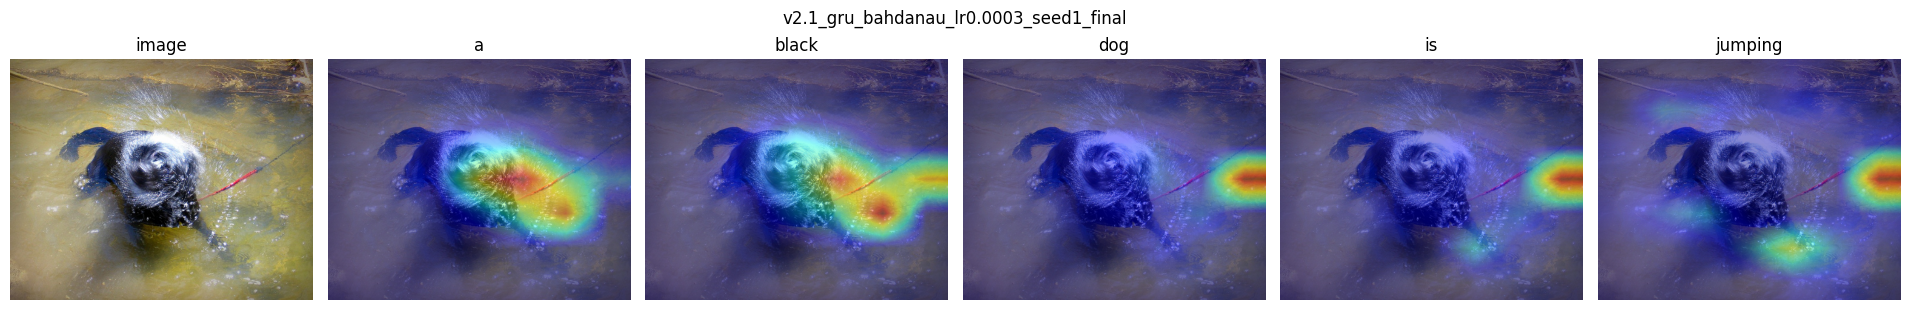

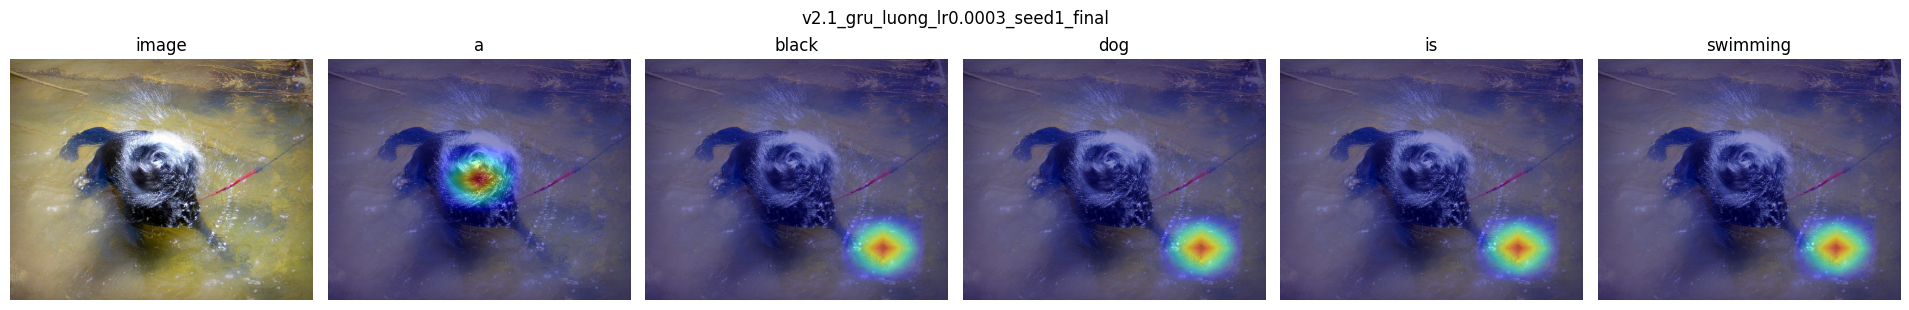

v2.1_gru_baseline_lr0.0003_seed1_final: n=1000 short=0 repeat=1 high_novelty=205
---
hyp: two dogs are running through a grassy area
ref: a big black dog jumps in the air to catch the tennis ball in his mouth
flags:   novel=0.50
---
hyp: a young boy with a blue <unk> <unk> and <unk> <unk>
ref: a child is laying in a bubble bath holding a yellow scrubbing brush up to his mouth as if singing into a microphone
flags:   novel=0.55
---
hyp: people are walking through a snowy area
ref: a group of people are ice skating in a big city
flags:   novel=0.57
---
hyp: two girls in blue shirts are playing in a park
ref: four children are playing in a grassy field
flags:   novel=0.50
---
hyp: a man in a black and white jacket is jumping into a lake
ref: a child gets squirted while squirting a water gun
flags:   novel=0.54
---
hyp: a boy in a blue shirt is jumping into a pool
ref: a child dressed in purple clothing and a hat runs in splashing water while a man and a small boy walk nearby
flags:   nove

{'n': 1000, 'short': 0, 'repeat': 7, 'high_novelty': 182}

In [29]:
## FINISH 4 — qualitative figures for the report
# Heatmaps for the winning attention model (Bahdanau) and the losing one (Luong) —
# the contrast is itself a finding. seed 1 at each model's SELECTED lr.
# Bahdanau won at 3e-4; Luong ran at 3e-4; adjust if your final LRs differ.
show_attention_heatmaps("gru_bahdanau", 3e-4, 1, n_words=5, sample_idx=12)
show_attention_heatmaps("gru_luong",    3e-4, 1, n_words=5, sample_idx=12)

# Failure analysis on the baseline and the best model, same image pool.
failure_analysis("gru_baseline", 3e-4, 1)
failure_analysis("gru_bahdanau", 3e-4, 1)